# **Análisis exploratorio de datos**

_____________

In [ ]:
# [Configuración] Importar librerías

# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
from statsmodels.graphics.tsaplots import plot_acf

# Geoespacial
import geopandas as gpd
from libpysal.weights import Queen
import libpysal

from esda.moran import Moran, Moran_Local

# Estadística clásica y no paramétrica
from scipy import stats
from scipy.stats import chi2_contingency, kruskal, shapiro
import scikit_posthocs as sp  # Pruebas post-hoc como Dunn

# Series temporales y detección de rupturas
import ruptures as rpt
from pymannkendall import original_test  # Tendencias en series temporales

ModuleNotFoundError: No module named 'esda'

In [ ]:
# [Configuración] Leer data
df = pd.read_csv(r"https://media.githubusercontent.com/media/Darally06/DATOS_DENGUE/refs/heads/main/Data_Atlantico.csv", encoding="latin_1")

# Leer shapefile
gdf = gpd.read_file("Datos adjuntos/Mapas_municipio/MGN_ADM_MPIO_GRAFICO.shp", encoding='utf_8')
gdf = gdf.rename(columns={'mpio_cnmbr': 'municipio'})
gdf = gdf[gdf['dpto_cnmbr'] == 'ATLÁNTICO']

#semanas = pd.read_csv("Resumen/consolidado_atlantico.csv")
#casos = pd.read_csv("Resumen/casos_mun_atlantico.csv")
poblacion = pd.read_csv("Datos adjuntos/Poblacion_departamental.csv", encoding="latin_1")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15032 entries, 0 to 15031
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   sexo            15032 non-null  object
 1   edad_años       15032 non-null  int64 
 2   ciclo_vital     15032 non-null  object
 3   grupo_etnico    15032 non-null  object
 4   regimen_salud   15032 non-null  object
 5   evento          15032 non-null  object
 6   tipo_caso       15032 non-null  object
 7   hospitalizado   15032 non-null  object
 8   desenlace       15032 non-null  object
 9   año             15032 non-null  int64 
 10  semana          15032 non-null  int64 
 11  periodo         15032 non-null  int64 
 12  fecha_ini_sint  15032 non-null  object
 13  fecha_consulta  15032 non-null  object
 14  fecha_hospital  15032 non-null  object
 15  fecha_notific   15032 non-null  object
 16  municipio       15032 non-null  object
 17  subregion       15032 non-null  object
 18  area  

> Para el este estudio se cuenta con 15,032 registros correspondientes a casos de dengue con ocurrencia en alguno de los 22 municipios del departamento del Atlántico, representado en 18 variables de estudio, en el periodo del año 2017 al año 2023.


## ***Descriptivo de variables***

In [ ]:
# [Función] Descripción de variables categóricas

def describir_categorica(columna, col_evento="evento"):
    tabla = pd.DataFrame({
        "Conteo": columna.value_counts(dropna=False),
        "Proporción": columna.value_counts(normalize=True, dropna=False).round(3)
    })

    tabla.index = tabla.index.map(lambda x: "NaN" if pd.isna(x) else x)
    crosstab_evento = pd.crosstab(df[columna.name], df[col_evento])
    tabla_completa = tabla.join(crosstab_evento)

    # Agregar proporciones específicas para 'Clasico' y 'Grave'
    if "Clasico" in crosstab_evento.columns:
        tabla_completa["Prop_Clasico"] = (tabla_completa["Clasico"] / tabla_completa["Conteo"]).round(3)
    else:
        tabla_completa["Prop_Clasico"] = 0
    if "Grave" in crosstab_evento.columns:
        tabla_completa["Prop_Grave"] = (tabla_completa["Grave"] / tabla_completa["Conteo"]).round(3)
    else:
        tabla_completa["Prop_Grave"] = 0

    print(f"\n📌 Variable: {columna.name}")
    print(tabla_completa)
    print("\n-----------------------------------")

### **Variables demográficas**

In [ ]:
describir_categorica(df["ciclo_vital"])
describir_categorica(df["sexo"])
describir_categorica(df["grupo_etnico"])
describir_categorica(df["regimen_salud"])



📌 Variable: ciclo_vital
                  Conteo  Proporción  Clasico  Grave  Prop_Clasico  Prop_Grave
ciclo_vital                                                                   
Adolescencia        6851       0.456     6669    182         0.973       0.027
Infancia            3367       0.224     3294     73         0.978       0.022
Adulto              3038       0.202     2945     93         0.969       0.031
Primera infancia    1412       0.094     1388     24         0.983       0.017
Adulto mayor         270       0.018      255     15         0.944       0.056
Menor de 1 año        69       0.005       68      1         0.986       0.014
Ancianidad            25       0.002       23      2         0.920       0.080

-----------------------------------

📌 Variable: sexo
           Conteo  Proporción  Clasico  Grave  Prop_Clasico  Prop_Grave
sexo                                                                   
Masculino    7875       0.524     7667    208         0.974      

La población infectada por dengue en el Atlántico está en su mayoría, en edad adolescente (45.6%), seguida de población infantes (22.4%) y adultos (20.2%); estos grupos etarios son los de mayor exposición al estar en el medio educativo y laboral. Se resalta que para la población adulto mayor y ancianidad, se presentan una proporción más elevada de dengue grave, lo que manifiesta una mayor vulnerabilidad clínica en estas etapas.

La distribución de casos por sexo es equilibrada, siento el 52.4% masculinos. En términos étnicos, solo un 2.4% de casos se asocia a pacientes pertenecientes a un grupo étnico. Los pacientes, en su mayoría están afiliados al régimen de salud subsidiado (53.2%) y contributivo (39.9%), no obstante, aunque la población de pacientes no asegurados representan apenas el 2.4% de los casos, concentran una mayor proporción de dengue grave (7.6%), lo que sugiere una posible asociación entre la ausencia de cobertura en salud y un peor desenlace clínico del dengue.

In [15]:
# [Análisis] Edad de los pacientes
df_edad = df[df["ciclo_vital"] != "Menor de 1 año"].copy()

orden_ciclos_edad = [
    "Primera infancia",
    "Infancia",
    "Adolescencia",
    "Adulto",
    "Adulto mayor",
    "Ancianidad"
]

df_edad["ciclo_vital"] = pd.Categorical(
    df_edad["ciclo_vital"],
    categories=orden_ciclos_edad,
    ordered=True
)

def tabla_descriptiva(df, variable, grupo=None):
    """
    Genera una tabla descriptiva (media, mediana, DE, IQR, etc.)
    por grupos (ej. ciclo vital).
    """
    if grupo:
        desc = df.groupby(grupo, observed=True)[variable].agg(
            n = 'count',
            media = 'mean',
            mediana = 'median',
            sd = 'std',
            q25 = lambda x: np.percentile(x, 25),
            q75 = lambda x: np.percentile(x, 75),
            minimo = 'min',
            maximo = 'max'
        ).reset_index()
    else:
        desc = df[variable].agg(
            n = 'count',
            media = 'mean',
            mediana = 'median',
            sd = 'std',
            q25 = lambda x: np.percentile(x, 25),
            q75 = lambda x: np.percentile(x, 75),
            minimo = 'min',
            maximo = 'max'
        ).to_frame().T
    return desc.round(2)

tabla = tabla_descriptiva(df_edad, variable="edad_años", grupo="ciclo_vital")
tabla

,ciclo_vital,n,media,mediana,sd,q25,q75,minimo,maximo
0,Primera infancia,1412,2.66,3.0,1.15,2.0,4.00,1,4
1,Infancia,3367,7.25,7.0,1.38,6.0,8.00,5,9
2,Adolescencia,6851,13.89,14.0,2.67,12.0,16.00,10,19
3,Adulto,3038,29.71,26.0,9.89,22.0,34.00,20,59
4,Adulto mayor,270,68.96,67.0,6.84,63.0,74.75,60,84
5,Ancianidad,25,88.64,88.0,3.38,86.0,90.00,85,97


La edad de los pacientes, diferenciada entre grupos etarios, se distribuye de la siguiente manera:

* Primera infancia [1-4 años]: Mayor concentración de edades al rededor de los 3 años.
* Infancia [5-9 años]: Edad concentrada entre los 6-8 años.
* Adolescencia [10-19 años]: Mayor cantidad de pacientes entre los 12-16 años.
* Adulto [20-59 años]: Mayoría de pacientes entre los 22-36 años.
* Adulto mayor [60 - 84 años]: Edades entre los 63-74 años.
* Ancianidad [85 -101 años]: Concentración de edades entre los 86-91 años.

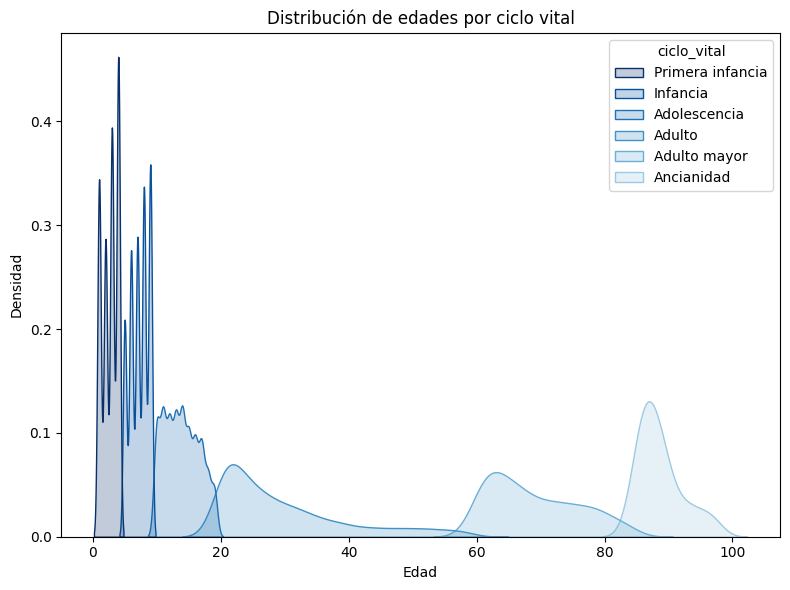

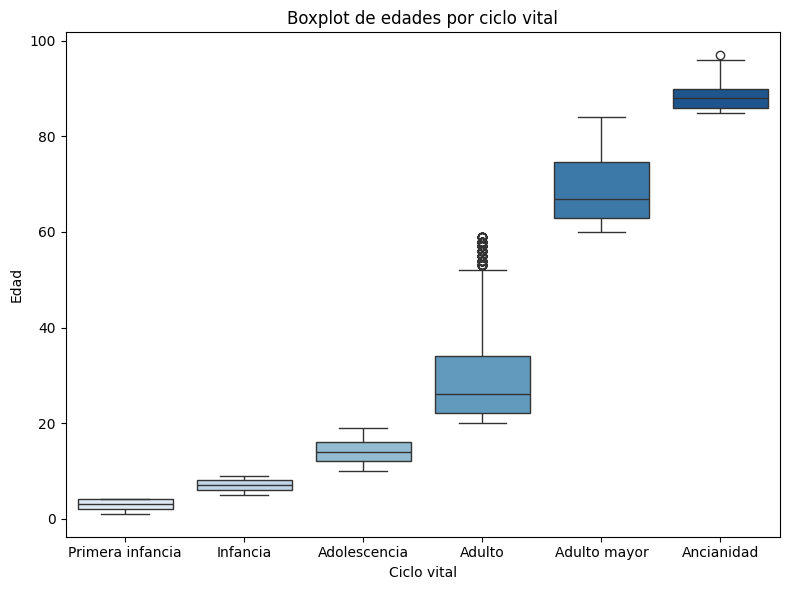

In [16]:
# [Gráfico] Distribución de edad
def graficos(df, variable, grupo):
    """
    Genera:
    1. Histograma + densidad global
    2. Densidad por ciclo vital
    3. Boxplot por ciclo vital
    """
    palette = ["#08306B", "#08519C", "#2171B5", "#4292C6", "#6BAED6", "#9ECAE1"]

    # --- 2. Densidad por ciclo vital ---
    plt.figure(figsize=(8,6))
    sns.kdeplot(data=df, x=variable, hue=grupo, common_norm=False, fill=True, palette=palette)
    plt.title("Distribución de edades por ciclo vital")
    plt.xlabel("Edad")
    plt.ylabel("Densidad")
    plt.tight_layout()
    plt.show()

    # --- 3. Boxplot por ciclo vital ---
    plt.figure(figsize=(8,6))
    sns.boxplot(data=df, x=grupo, hue=grupo, y=variable, palette="Blues")
    plt.title("Boxplot de edades por ciclo vital")
    plt.xlabel("Ciclo vital")
    plt.ylabel("Edad")
    plt.tight_layout()
    plt.show()

graficos(df_edad, variable="edad_años", grupo="ciclo_vital")

Los gráficos representan la distribución de la edad, discriminada por grupos etarios, donde se evidencia que para las primeras etapas de la vida, la distribución de la edad de los pacientes es homogénea. La etapa adulta es la de mayor variabilidad, con sesgo positivo, lo que indica una mayor proporción de casos hacia los adultos mas jóvenes. Misma dinámica se aprecia para el grupo Adulto mayor y Ancianidad.

### **Variables de evento**

In [17]:

describir_categorica(df['evento'])
describir_categorica(df['tipo_caso'])
describir_categorica(df['hospitalizado'])
describir_categorica(df['desenlace'])


📌 Variable: evento
         Conteo  Proporción  Clasico  Grave  Prop_Clasico  Prop_Grave
evento                                                               
Clasico   14642       0.974    14642      0           1.0         0.0
Grave       390       0.026        0    390           0.0         1.0

-----------------------------------

📌 Variable: tipo_caso
                       Conteo  Proporción  Clasico  Grave  Prop_Clasico  \
tipo_caso                                                                 
Probable                10273       0.683     9984    289         0.972   
Conf. por laboratorio    4716       0.314     4615    101         0.979   
Conf. por nexo             43       0.003       43      0         1.000   

                       Prop_Grave  
tipo_caso                          
Probable                    0.028  
Conf. por laboratorio       0.021  
Conf. por nexo              0.000  

-----------------------------------

📌 Variable: hospitalizado
               Conte

El dengue clásico en el Atlántico tiene una representatividad del 97.4% de casos (14,642) frente al 2.6% de casos graves (390) en todo el territorio. En su mayoría los registros analizados corresponden a casos probables (68.3%), solo el 31.4% fueron casos confirmados por prueba en laboratorio. Todos los casos confirmados por nexo epidemiológico (43) se relacionan al dengue clásico.

De los casos registrados, se tiene que el 63.3% de los pacientes requirieron hospitalización, mientras que el 36.7% fueron manejados de manera ambulatoria. De los 390 casos de dengue grave, 10 no fueron hospitalizados.

En relación a los fallecidos, la mortalidad registrada es mínima, existiendo solo 7 pacientes fallecidos, todos por dengue grave.

### **Variables espaciales**

#### *Casos netos*

In [18]:
print("DESCRIPCIÓN DE VARIABLES ESPACIALES")

describir_categorica(df["area"])
describir_categorica(df['municipio'])
describir_categorica(df['subregion'])

DESCRIPCIÓN DE VARIABLES ESPACIALES

📌 Variable: area
                    Conteo  Proporción  Clasico  Grave  Prop_Clasico  \
area                                                                   
Cabecera municipal   14387       0.957    14011    376         0.974   
Centro poblado         564       0.038      551     13         0.977   
Rural disperso          81       0.005       80      1         0.988   

                    Prop_Grave  
area                            
Cabecera municipal       0.026  
Centro poblado           0.023  
Rural disperso           0.012  

-----------------------------------

📌 Variable: municipio
                  Conteo  Proporción  Clasico  Grave  Prop_Clasico  Prop_Grave
municipio                                                                     
SOLEDAD             6997       0.465     6841    156         0.978       0.022
MALAMBO             1697       0.113     1657     40         0.976       0.024
SABANALARGA         1093       0.073     106

Los casos de dengue se registraron en su mayoría en una cabecera municipal (95.7%), siendo solo el 4.3% en un centro poblado o rural disperso.

La dinámica por municipios es variada, en datos netos, la mitad de los casos se concentra en el municipio de Soledad (46.5%) con 6,841 casos, de los cuales 156 son relacionados con el dengue grave.

Luego, los municipios de Malambo, Baranoa y Sabanalarga, constituyen un bloque de más de 1,000 casos reportados, conformando el núcleo de mayor transmisión. Cabe resaltar que en el municipio de Puerto Colombia, se registro la mayor cantidad de casos graves (56) después de Soledad.

Con menor representatividad, sin superar los 100 registros, se encuentran los municipios de Sabanagrande, Tubará, Santo Tomás,  Piojó, Candelaria y Santa Lucía, este último.

En resumen, la epidemia de dengue en el departamento del Atlántico presenta un patrón predominante urbano, con concentración en los municipios del área metropolitana y céntrica, lo cual podría reflejar tanto características locales de transmisión como posibles diferencias en el acceso a diagnóstico oportuno.

#### _Municipio_

In [19]:
# [Tabla] Casos por municipio
tabla_mun = df.groupby(["municipio", "año", "evento"]).size().reset_index(name="casos")
totales_mun = tabla_mun.groupby("municipio")["casos"].sum()

In [ ]:
totales_mun.describe()

count      22.000000
mean      683.272727
std      1476.184341
min        41.000000
25%       100.750000
50%       220.500000
75%       684.750000
max      6997.000000
Name: casos, dtype: float64

Tomando el total de casos, por cada municipio se registraron como mínimo 27 eventos y máximo 8,791. En promedio se tiene un registro de 808 casos por municipio, con una desviación alta de 1,815 registros. El 50% de los municipios tiene un reporte entre 124 a 694 casos.

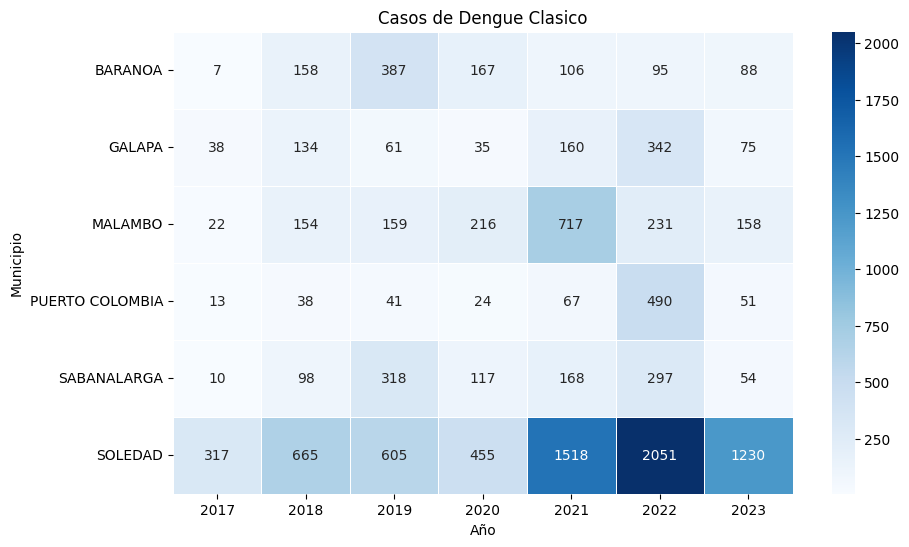

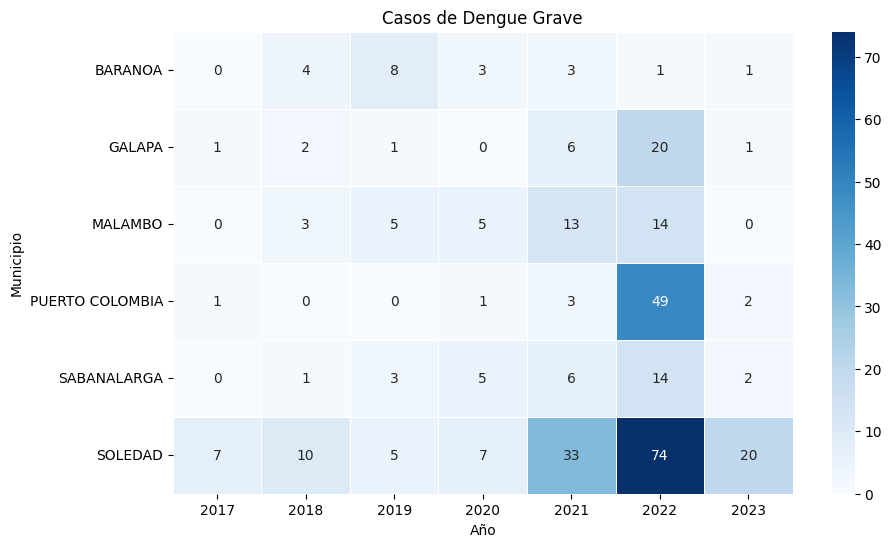

In [20]:
# [Gráfico] Tabla casos por municipio

totales_mun = tabla_mun.groupby("municipio")["casos"].sum()
municipios_filtrados = totales_mun[totales_mun > 650].index
tabla_filtrada = tabla_mun[tabla_mun["municipio"].isin(municipios_filtrados)]

eventos = ["Clasico", "Grave"]

for evento in eventos:
    tabla_evento = tabla_filtrada[tabla_filtrada["evento"] == evento]

    # Crear tabla pivote
    pivot = tabla_evento.pivot_table(
        index="municipio",
        columns="año",
        values="casos",
        fill_value=0
    ).astype(int)

    # Graficar
    plt.figure(figsize=(10,6))
    sns.heatmap(pivot, cmap="Blues", linewidths=0.5, annot=True, fmt="d")
    plt.title(f"Casos de Dengue {evento}")
    plt.xlabel("Año")
    plt.ylabel("Municipio")
    plt.show()


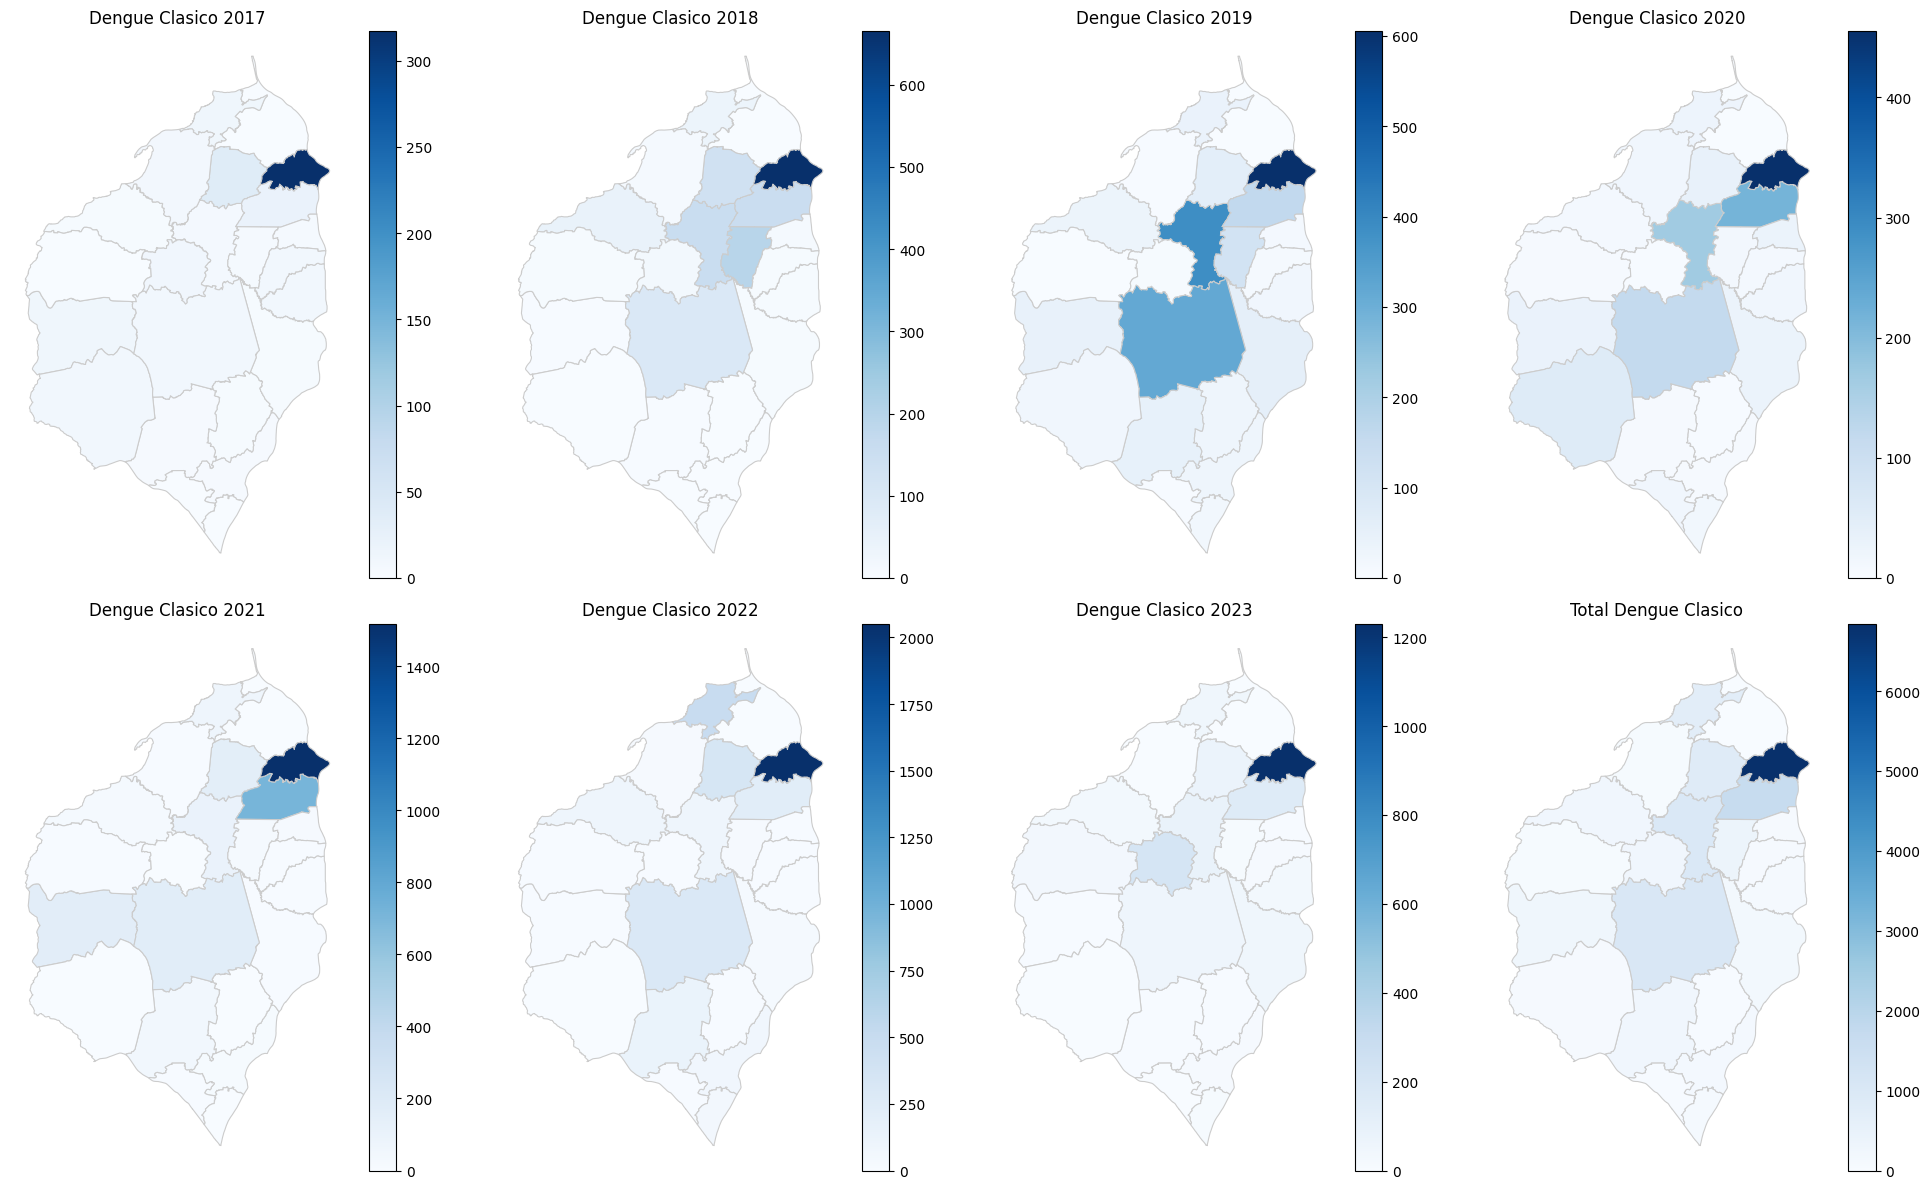

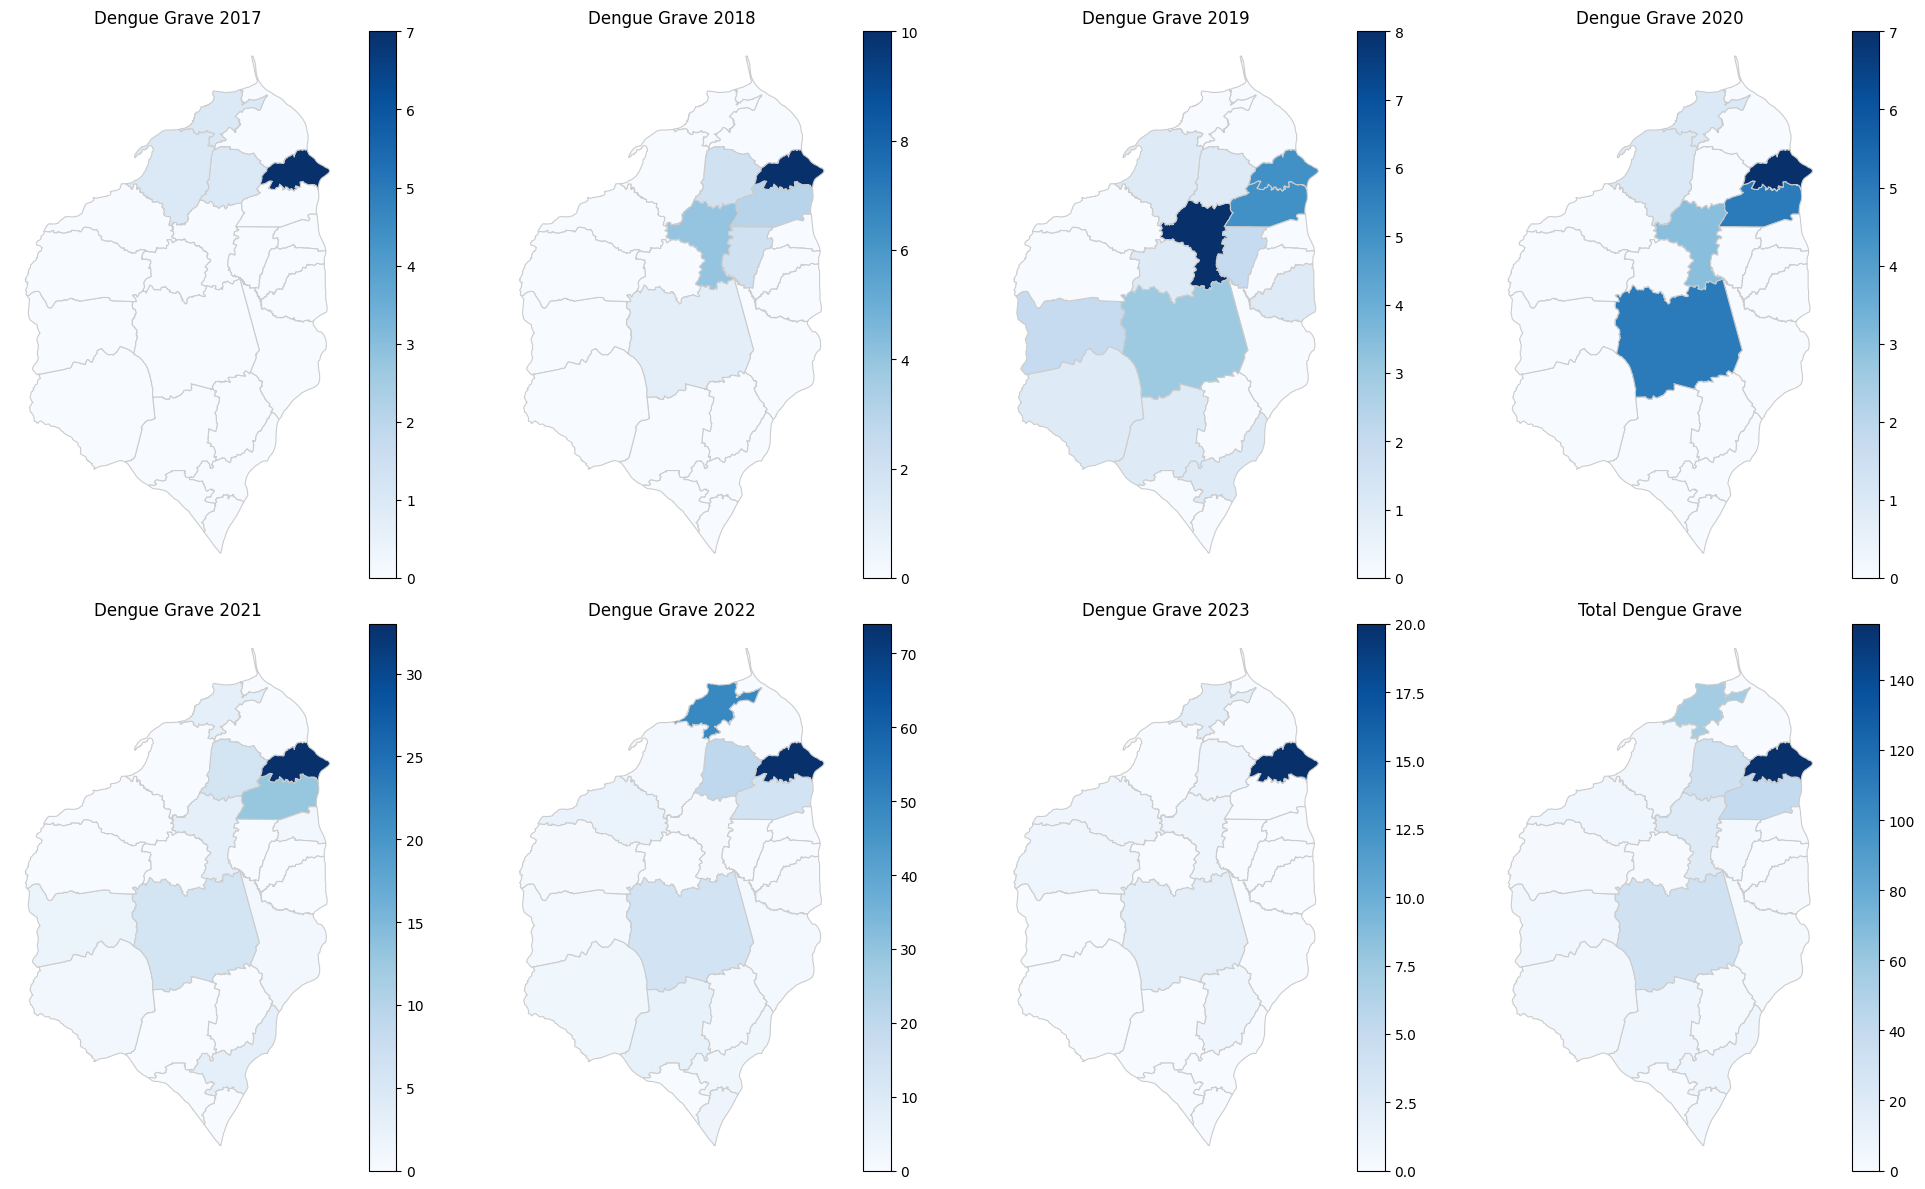

In [21]:
eventos = ["Clasico", "Grave"]

for evento in eventos:
    anios = sorted(df["año"].unique())[:7]  # 6 años
    n = len(anios) + 1  # +1 para el total

    columnas = 4
    filas = 2

    fig, axes = plt.subplots(filas, columnas, figsize=(5*columnas, 6*filas))
    axes = axes.flatten()

    # Mapas por año
    for i, anio in enumerate(anios):
        casos_anio = (
            df[(df["año"] == anio) & (df["evento"] == evento)]
            .groupby("municipio")
            .size()
            .reset_index(name="CASOS")
        )

        gdf_plot = gdf.merge(casos_anio, on="municipio", how="left").fillna(0)

        gdf_plot.plot(column="CASOS", cmap="Blues", linewidth=0.8, edgecolor="0.8",
                      legend=True, ax=axes[i])
        axes[i].set_title(f"Dengue {evento} {anio}")
        axes[i].axis("off")

    # Mapa total (último subplot)
    casos_total = (
        df[df["evento"] == evento]
        .groupby("municipio")
        .size()
        .reset_index(name="CASOS")
    )

    gdf_total = gdf.merge(casos_total, on="municipio", how="left").fillna(0)

    gdf_total.plot(column="CASOS", cmap="Blues", linewidth=0.8, edgecolor="0.8",
                   legend=True, ax=axes[len(anios)])
    axes[len(anios)].set_title(f"Total Dengue {evento}")
    axes[len(anios)].axis("off")

    # Ocultar subplots vacíos (si sobran)
    for j in range(len(anios) + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


#### _Subregión_

In [22]:
# [Tabla] Casos por sub-región
tabla_rg = df.groupby(["subregion", "año", "evento"]).size().reset_index(name="casos")
totales_rg = tabla_rg.groupby("subregion")["casos"].sum()

In [ ]:
totales_rg.describe()

count        5.000000
mean      3006.400000
std       4250.248263
min        405.000000
25%        482.000000
50%        729.000000
75%       3066.000000
max      10350.000000
Name: casos, dtype: float64

Tomando el total de casos, por cada sub región se registraron como mínimo 27 eventos y máximo 8,791. En promedio se tiene un registro de 808 casos por municipio, con una desviación alta de 1,815 registros. El 50% de los municipios tiene un reporte entre 124 a 694 casos.

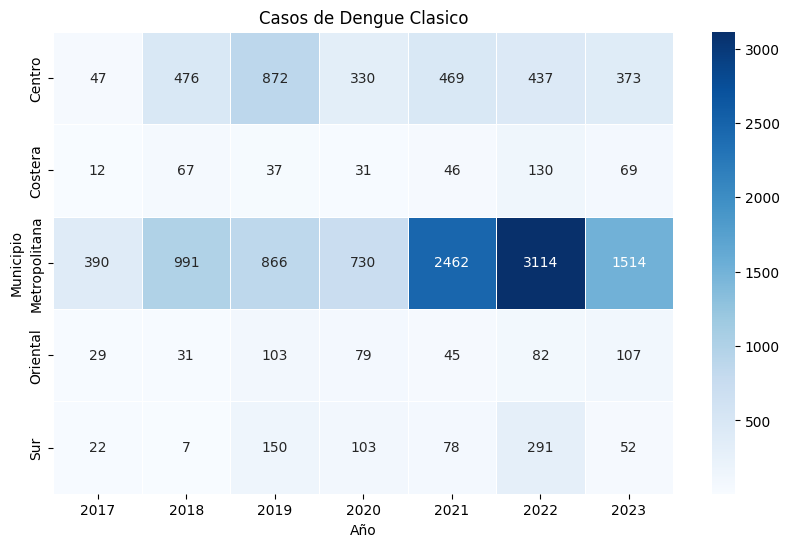

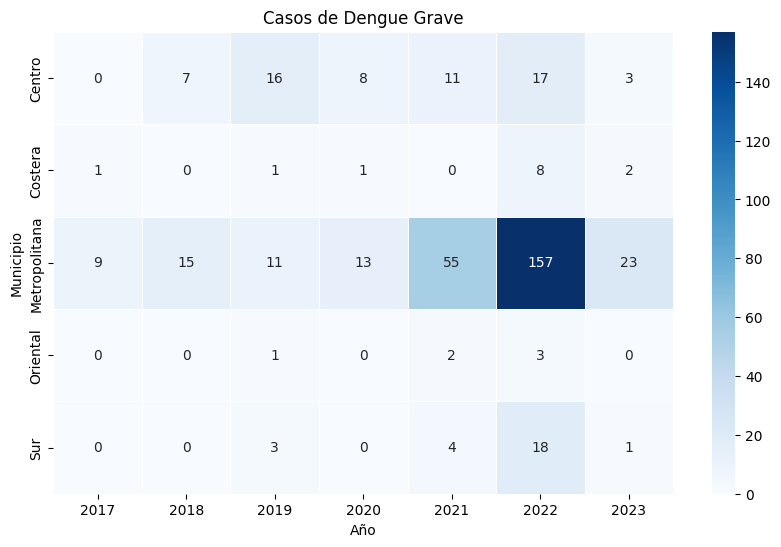

In [23]:
# [Gráfico] Tabla casos por subregion
eventos = ["Clasico", "Grave"]

for evento in eventos:
    tabla_evento = tabla_rg[tabla_rg["evento"] == evento]

    # Crear tabla pivote: subregión vs año
    pivot = tabla_evento.pivot_table(
        index="subregion",
        columns="año",
        values="casos",
        fill_value=0
    ).astype(int)

    # Graficar
    plt.figure(figsize=(10,6))
    sns.heatmap(pivot, cmap="Blues", linewidths=0.5, annot=True, fmt="d")
    plt.title(f"Casos de Dengue {evento}")
    plt.xlabel("Año")
    plt.ylabel("Municipio")
    plt.show()


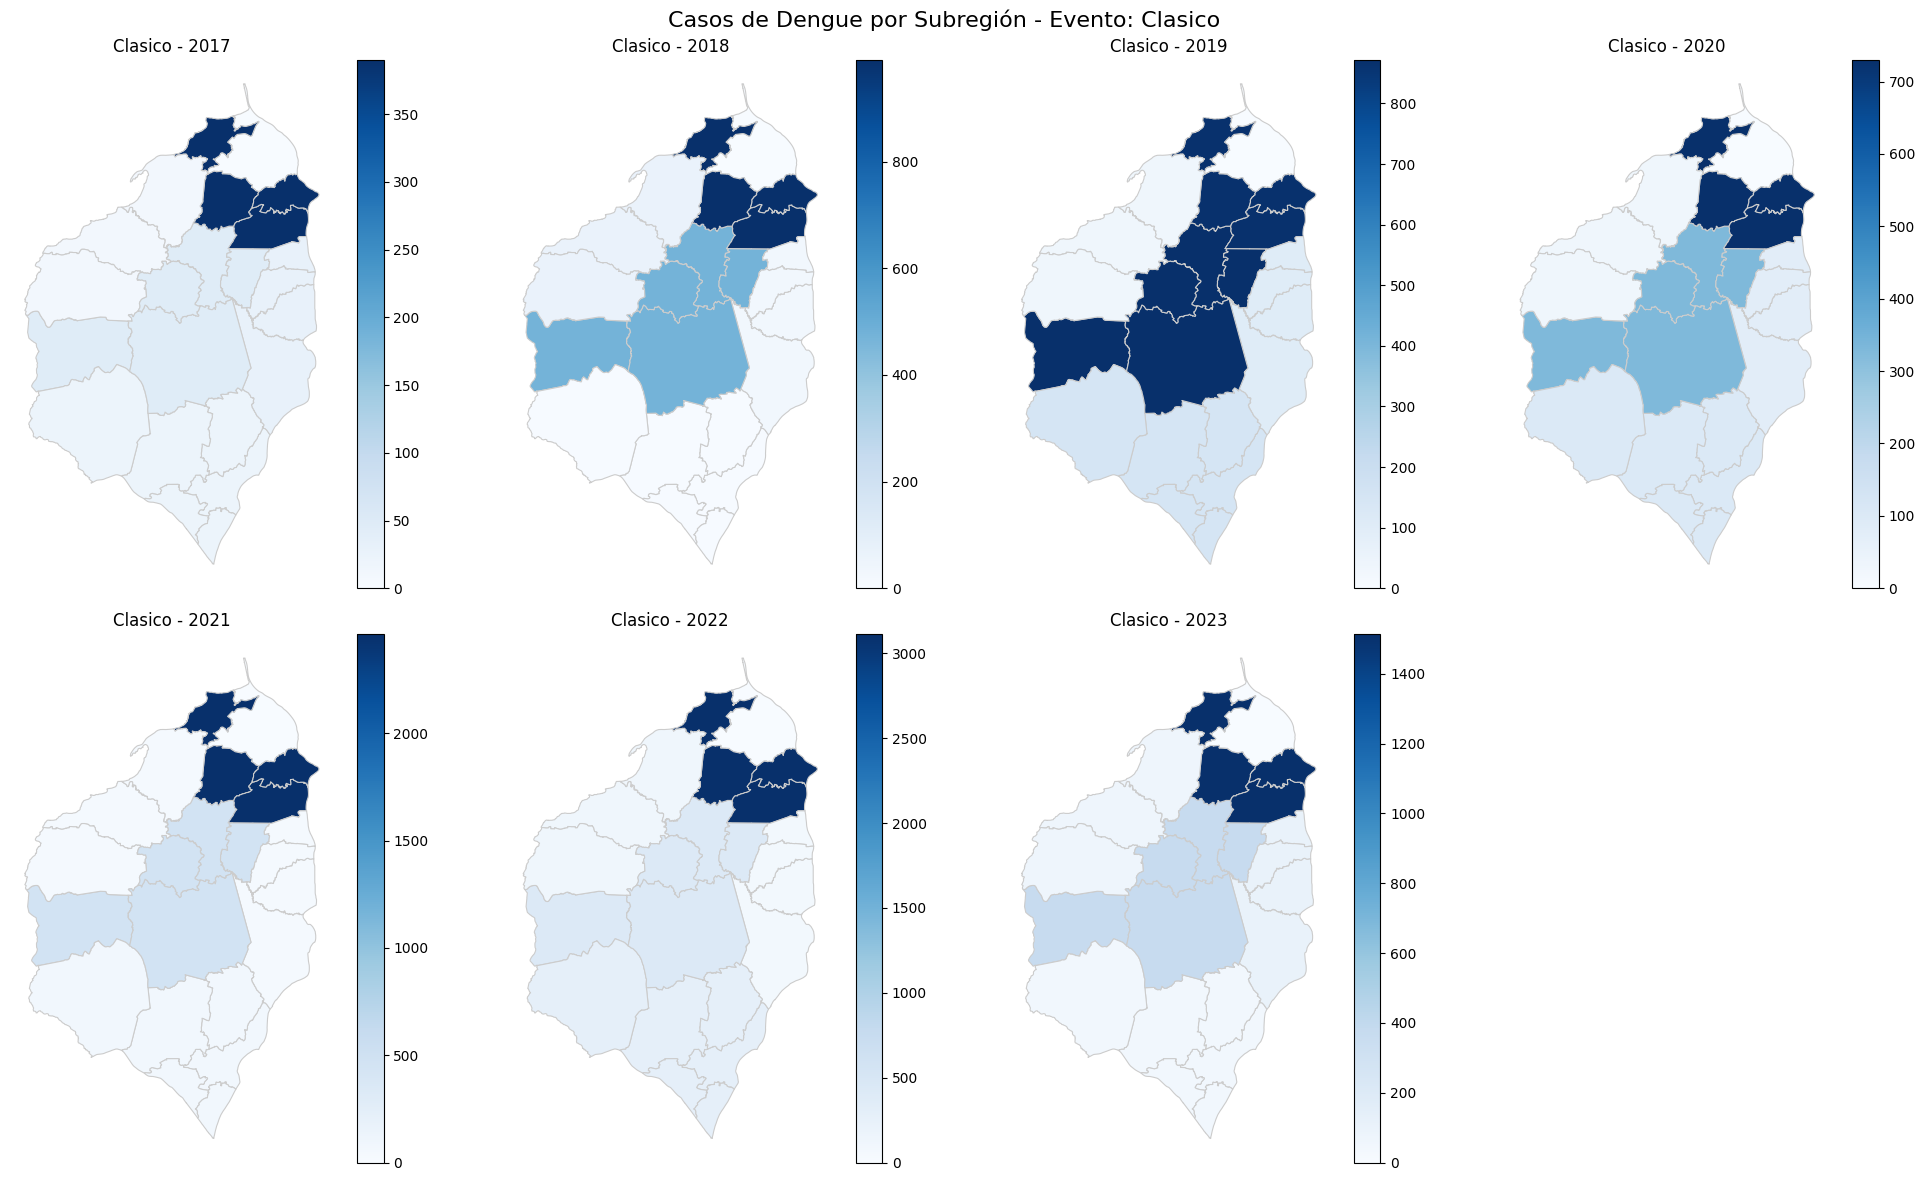

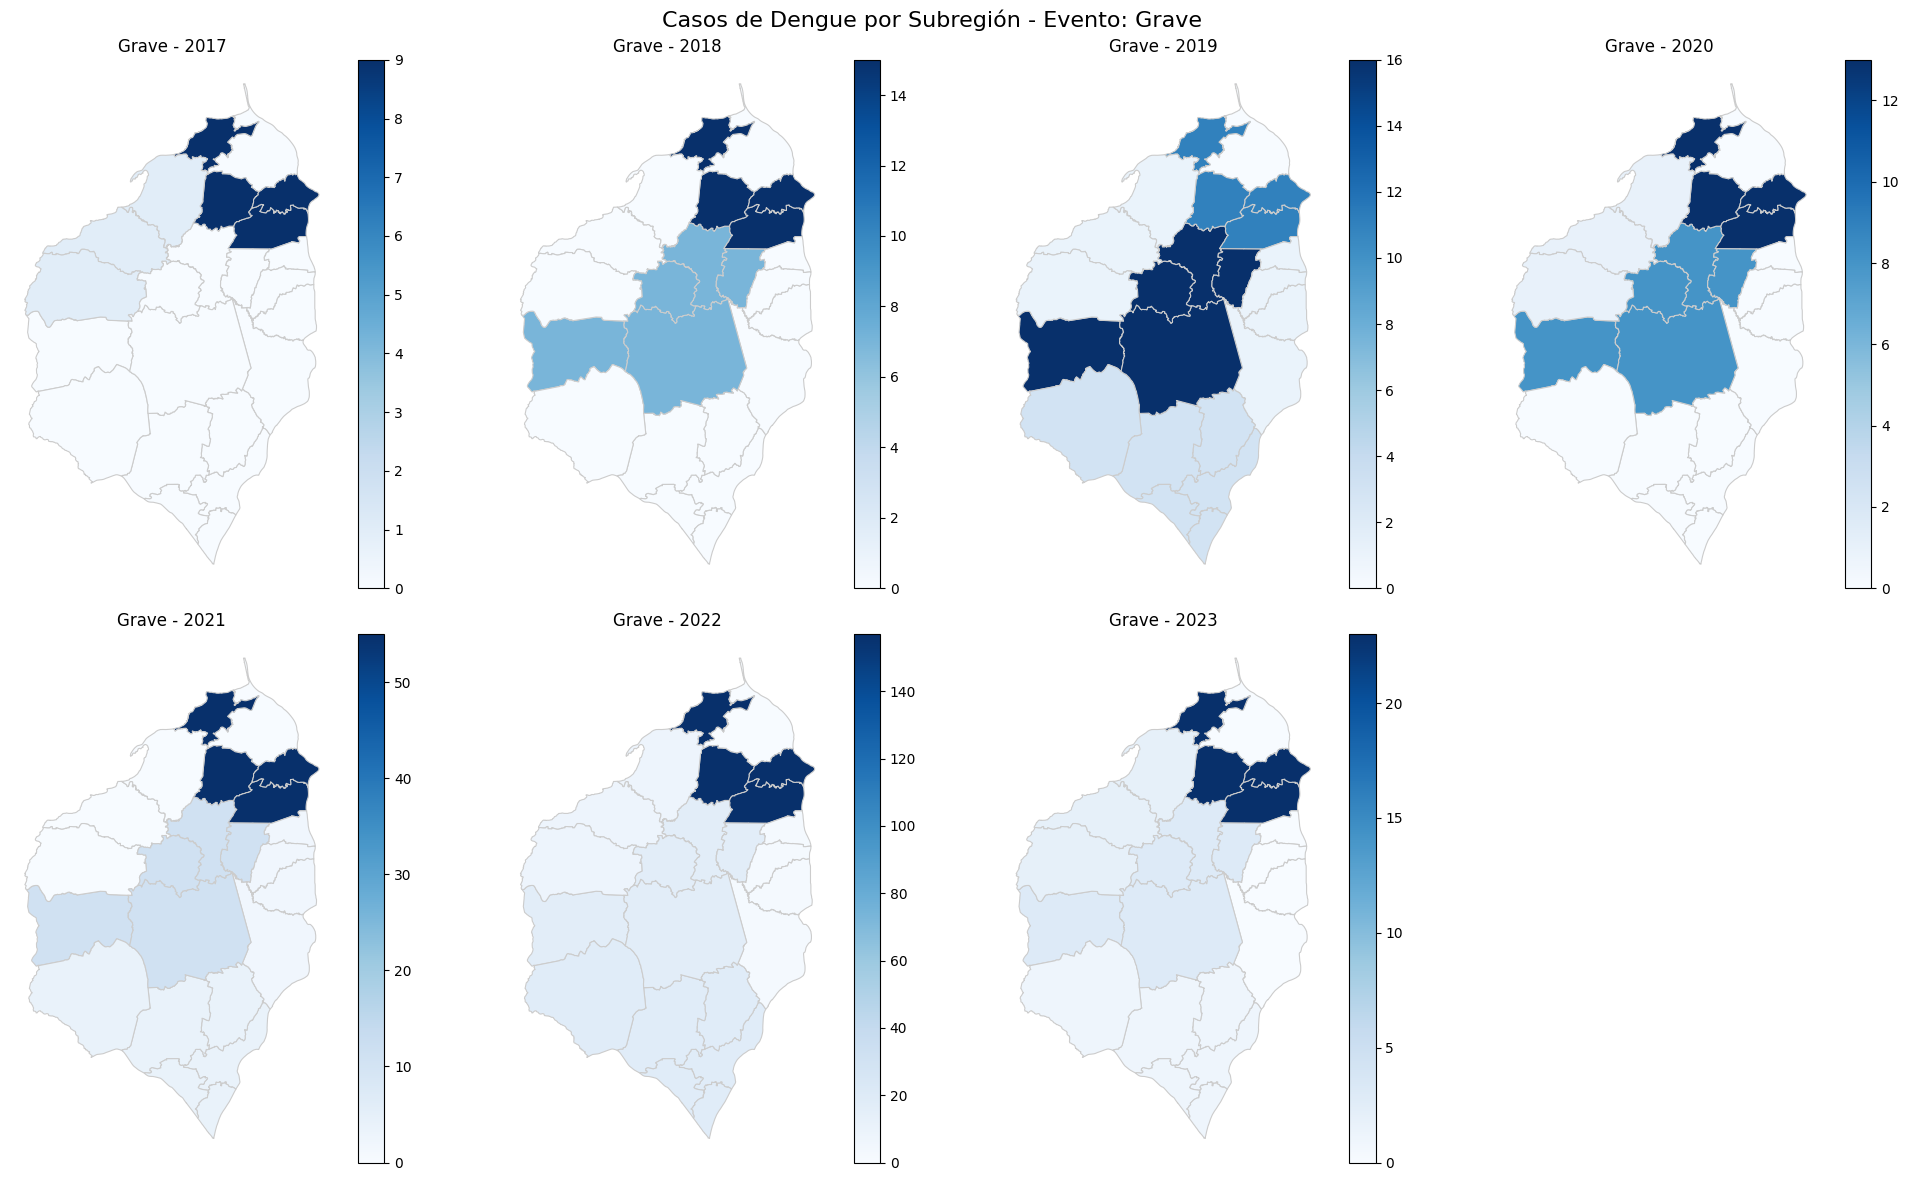

In [24]:
# Asegurar que cada municipio en gdf tenga su subregión
if 'subregion' in gdf.columns:
    gdf = gdf.drop(columns='subregion')

# Ahora sí puedes hacer el merge sin conflicto
gdf = gdf.merge(df[['municipio', 'subregion']].drop_duplicates(), on='municipio', how='left')

eventos = ["Clasico", "Grave"]
anios = sorted(df["año"].unique())[:7]  # Limitar a 6 años si deseas

columnas = 4
filas = 2

for evento in eventos:
    fig, axes = plt.subplots(filas, columnas, figsize=(5*columnas, 6*filas))
    axes = axes.flatten()

    for i, anio in enumerate(anios):
        # Casos por subregión en ese año y evento
        casos_subregion = (
            df[(df["año"] == anio) & (df["evento"] == evento)]
            .groupby("subregion")
            .size()
            .reset_index(name="casos")
        )

        # Asignar casos a cada municipio según su subregión
        gdf_plot = gdf.merge(casos_subregion, on="subregion", how="left").fillna(0)

        # Graficar
        gdf_plot.plot(column="casos", cmap="Blues", linewidth=0.8, edgecolor="0.8",
                      legend=True, ax=axes[i])
        axes[i].set_title(f"{evento} - {anio}")
        axes[i].axis("off")

    # Ocultar subplots vacíos si sobran
    for j in range(len(anios), len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"Casos de Dengue por Subregión - Evento: {evento}", fontsize=16)
    plt.tight_layout()
    plt.show()

### **Variables temporales**

#### _Año_

In [25]:
describir_categorica(df["año"])


📌 Variable: año
      Conteo  Proporción  Clasico  Grave  Prop_Clasico  Prop_Grave
año                                                               
2022    4257       0.283     4054    203         0.952       0.048
2021    3172       0.211     3100     72         0.977       0.023
2023    2144       0.143     2115     29         0.986       0.014
2019    2060       0.137     2028     32         0.984       0.016
2018    1594       0.106     1572     22         0.986       0.014
2020    1295       0.086     1273     22         0.983       0.017
2017     510       0.034      500     10         0.980       0.020

-----------------------------------


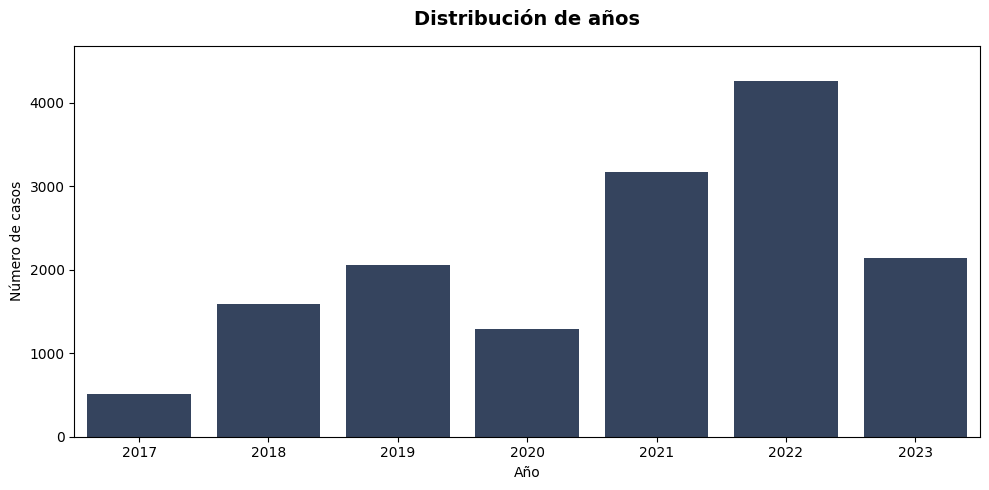

In [26]:
# [Gráfico] Distribución por años
conteo_por_año = df['año'].value_counts(sort=False).sort_index()

    # Crear gráfico
plt.figure(figsize=(10, 5))
sns.barplot(x=conteo_por_año.index.astype(str), y=conteo_por_año.values, color='#2E4265')

plt.title('Distribución de años', fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Año")
plt.ylabel("Número de casos")
plt.xticks(rotation=0)
plt.ylim(0, max(conteo_por_año.values) * 1.1)
plt.tight_layout()
plt.show()


La variabilidad de los casos en el tiempo, muestra una notoria tendencia hacía la alza al pasar de los años, con variaciones importantes. Del 2017 al 2019, se obtienen la menor cantidad de registros, solo el 27% de los casos se dieron en este tiempo. En este periodo se evidencia un ciclo de crecimiento con caída hacia el 2020, para seguir la tendencia de crecimiento hacia el 2023. El año 2022, es el que mayor registro de casos de dengue grave presenta, unos 203 pacientes.

#### _Semana_

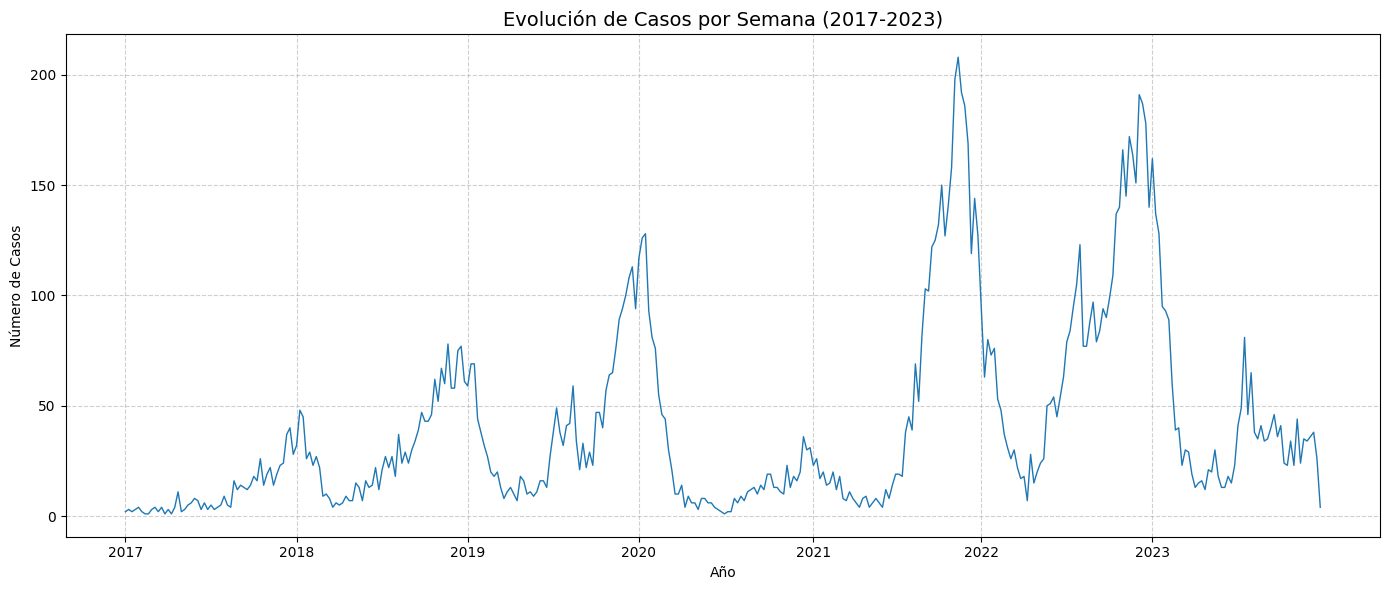

In [27]:
# [Gráfico] Casos por semana
casos_semana = df.groupby(["año", "semana"]).size().reset_index(name="casos")
casos_semana = casos_semana.sort_values(["año", "semana"]).reset_index(drop=True)
casos_semana["index"] = range(len(casos_semana))

# Graficar
plt.figure(figsize=(14, 6))
plt.plot(casos_semana["index"], casos_semana["casos"], linewidth=1)
años_unicos = casos_semana["año"].unique()
ticks = [casos_semana[casos_semana["año"] == año].index[0] for año in años_unicos]
plt.xticks(ticks, años_unicos, fontsize=10)
plt.title("Evolución de Casos por Semana (2017-2023)", fontsize=14)
plt.xlabel("Año")
plt.ylabel("Número de Casos")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

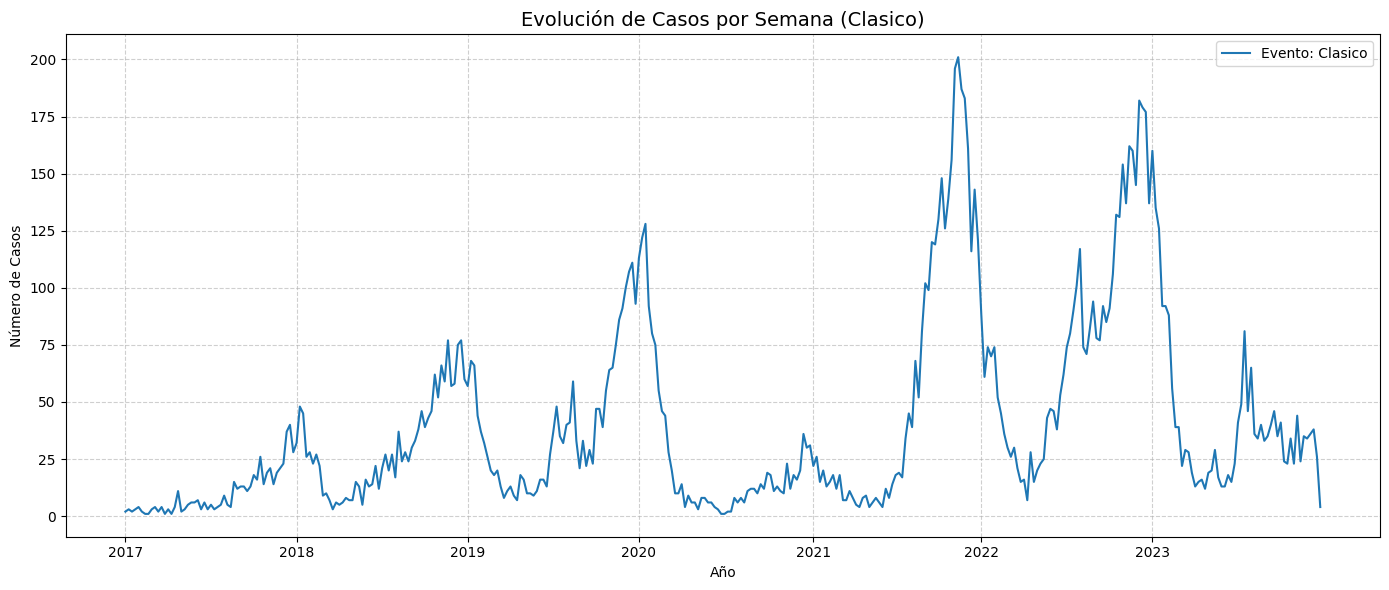

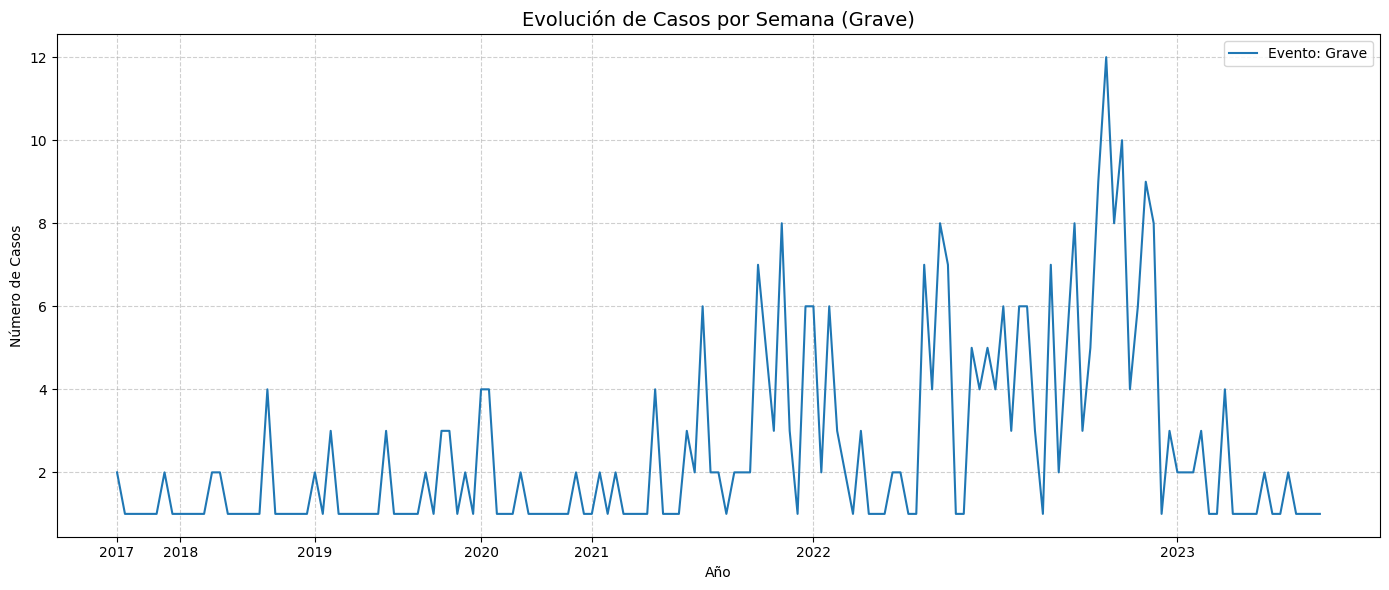

In [28]:
eventos = df["evento"].unique()

for ev in eventos:
    # Filtrar por evento
    df_evento = df[df["evento"] == ev]

    # Agrupar por semana y año
    casos_evento = df_evento.groupby(["año", "semana"]).size().reset_index(name="casos")
    casos_evento = casos_evento.sort_values(["año", "semana"]).reset_index(drop=True)
    casos_evento["index"] = range(len(casos_evento))

    # Graficar
    plt.figure(figsize=(14, 6))
    plt.plot(casos_evento["index"], casos_evento["casos"], linewidth=1.5, label=f"Evento: {ev}")

    años_unicos = casos_evento["año"].unique()
    ticks = [casos_evento[casos_evento["año"] == año].index[0] for año in años_unicos]
    plt.xticks(ticks, años_unicos, fontsize=10)

    plt.title(f"Evolución de Casos por Semana ({ev})", fontsize=14)
    plt.xlabel("Año")
    plt.ylabel("Número de Casos")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.legend()
    plt.show()

In [29]:
week = tabla_descriptiva(df_edad, variable="semana", grupo="año")
week

,año,n,media,mediana,sd,q25,q75,minimo,maximo
0,2017,503,38.37,42.0,12.61,33.0,48.5,1,52
1,2018,1585,33.62,39.0,16.09,24.0,47.0,1,52
2,2019,2047,32.74,38.0,16.95,21.0,47.0,1,52
3,2020,1287,17.04,7.0,18.23,3.0,35.0,1,53
4,2021,3158,39.97,43.0,11.15,37.0,47.0,1,52
5,2022,4245,33.81,38.0,15.08,26.0,46.0,1,52
6,2023,2138,21.33,21.0,16.57,5.0,36.0,1,52


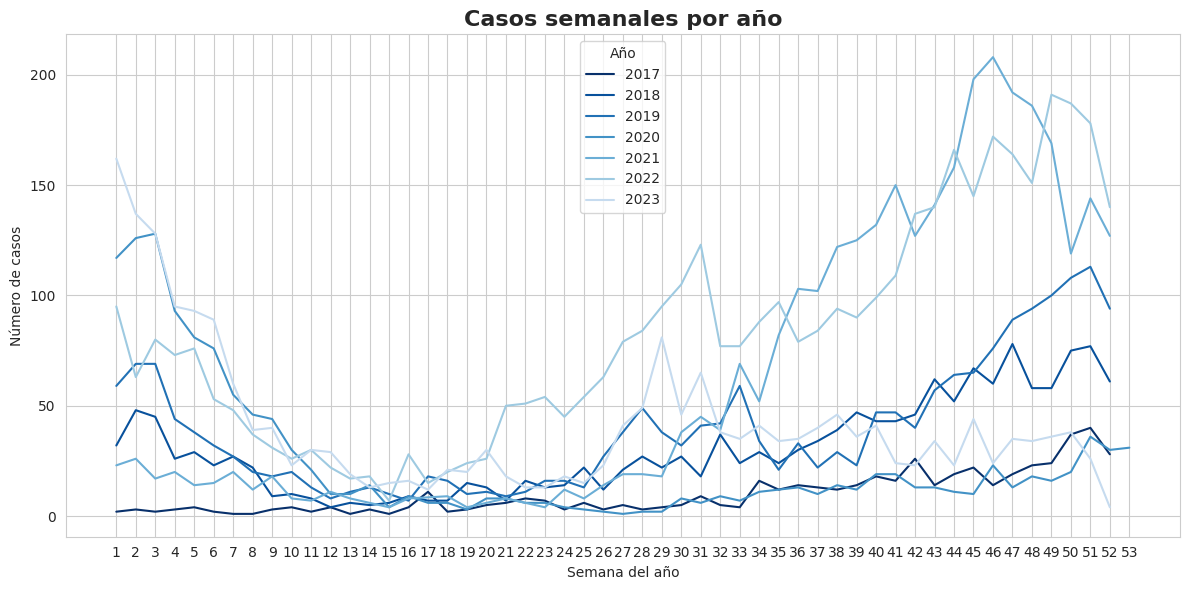

In [30]:
# Contar casos por semana y año
conteo_semanal = df.groupby(['año', 'semana']).size().reset_index(name='casos')

def graficar_casos_semanales_por_año(df_conteo, nombre_grafico="Casos semanales por año"):
    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")

    años = sorted(df_conteo['año'].unique())

    palette = ["#08306B", "#08519C", "#2171B5", "#4292C6", "#6BAED6", "#9ECAE1", "#C6DBEF"]
    colores = palette[:len(años)]  # selecciona N colores según la cantidad de años

    for i, año in enumerate(años):
        datos_año = df_conteo[df_conteo['año'] == año]
        plt.plot(
            datos_año['semana'],
            datos_año['casos'],
            label=str(año),
            color=colores[i]
        )

    plt.title(nombre_grafico, fontsize=16, fontweight='bold')
    plt.xlabel("Semana del año")
    plt.ylabel("Número de casos")
    plt.xticks(range(1, 54))  # Semanas ISO van de 1 a 53
    plt.legend(title="Año")
    plt.tight_layout()
    plt.show()


graficar_casos_semanales_por_año(conteo_semanal)

In [31]:
# Agrupar y pivotear
conteo_semanal_semanal = df.groupby(['año', 'semana']).size().reset_index(name='casos')
tabla_pivot = conteo_semanal.pivot(index='año', columns='semana', values='casos').fillna(0).astype(int)
# Crear lista para almacenar resultados
resumen_semanas = []
for año in tabla_pivot.index:
    fila = tabla_pivot.loc[año]
    semana_max = fila.idxmax()
    casos_max = fila.max()
    resumen_semanas.append({
        "año": año,
        "semana_más_casos": semana_max,
        "casos_máximos": casos_max,
    })
tabla_resumen = pd.DataFrame(resumen_semanas)
tabla_resumen


,año,semana_más_casos,casos_máximos
0,2017,51,40
1,2018,47,78
2,2019,51,113
3,2020,3,128
4,2021,46,208
5,2022,49,191
6,2023,1,162


Al detallar los registros por la semana epidemiológica, se evidencia que existe un aumento de casos hacia los últimos meses de cada año, con algunos picos hacia la mitad del año.

En promedio, los casos se dan en su mayoría entre la semana 28 y la semana 44, con una media de distribución hacia la semana 30. Se destaca que el record de casos fue de 250 en la primera semana del 2023.

Con respecto a cada año, la mayor variabilidad se evidencia en el 2023. Los años 2021 y 2022, presentan notados picos de alza hacia finales de cada año. El 2017 y el 2020, son los años de manor variabilidad.

#### _Periodo_

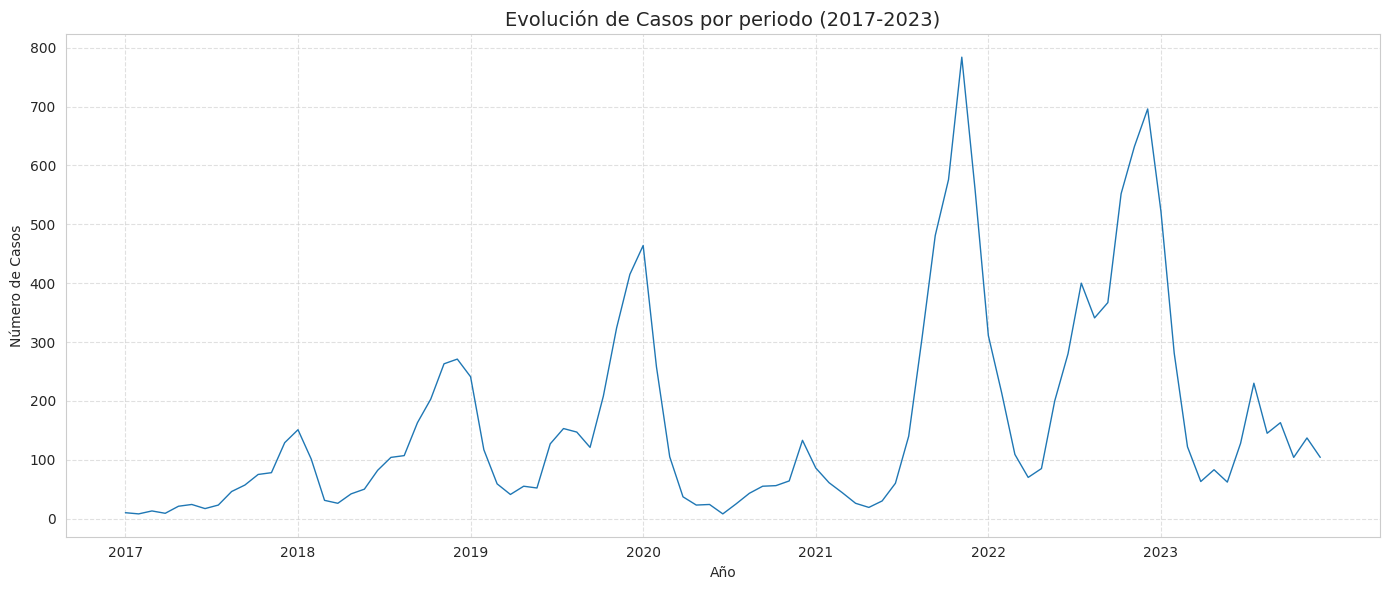

In [32]:
# [Gráfico] Casos por periodo
casos_periodo = df.groupby(["año", "periodo"]).size().reset_index(name="casos")
casos_periodo = casos_periodo.sort_values(["año", "periodo"]).reset_index(drop=True)
casos_periodo["index"] = range(len(casos_periodo))

# Graficar
plt.figure(figsize=(14, 6))
plt.plot(casos_periodo["index"], casos_periodo["casos"], linewidth=1)
años_unicos = casos_periodo["año"].unique()
ticks = [casos_periodo[casos_periodo["año"] == año].index[0] for año in años_unicos]
plt.xticks(ticks, años_unicos, fontsize=10)
plt.title("Evolución de Casos por periodo (2017-2023)", fontsize=14)
plt.xlabel("Año")
plt.ylabel("Número de Casos")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

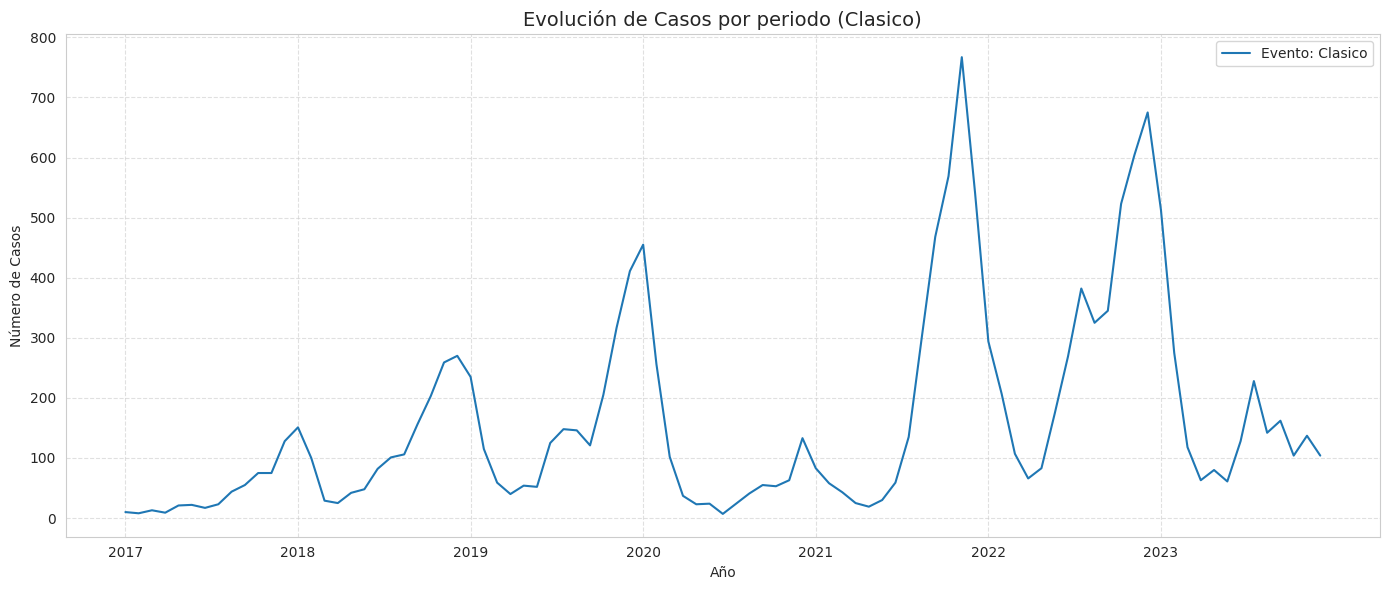

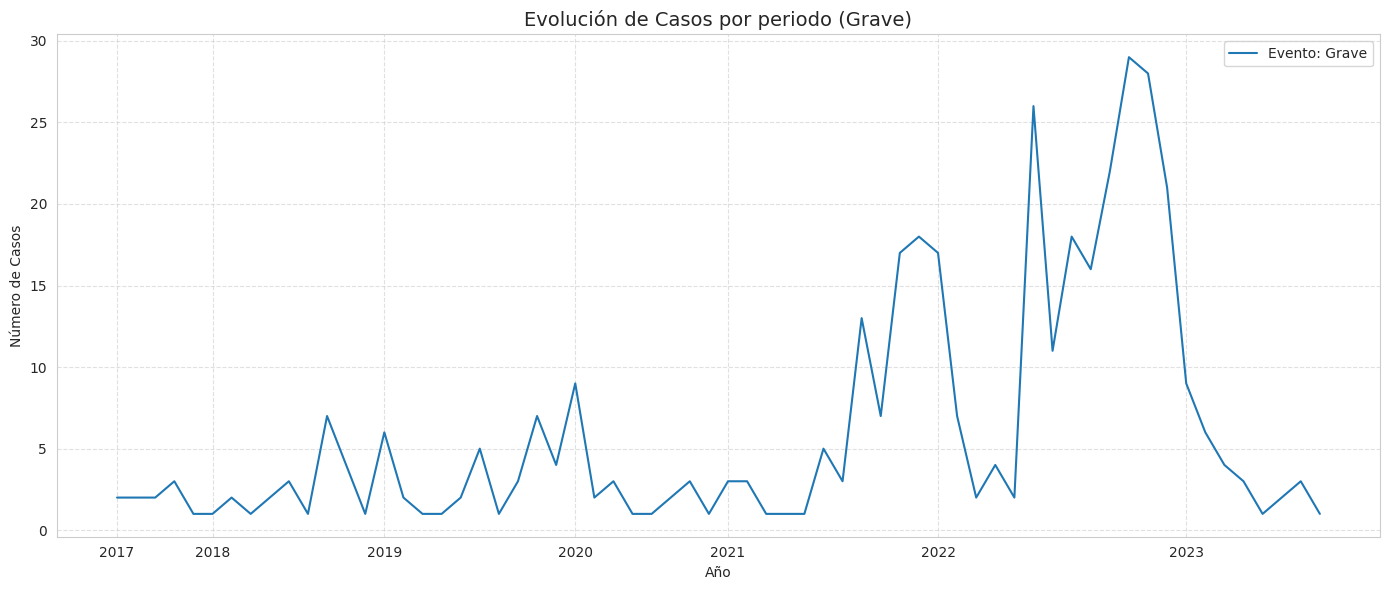

In [33]:
eventos = df["evento"].unique()

for ev in eventos:
    # Filtrar por evento
    df_evento = df[df["evento"] == ev]

    # Agrupar por periodo y año
    casos_evento = df_evento.groupby(["año", "periodo"]).size().reset_index(name="casos")
    casos_evento = casos_evento.sort_values(["año", "periodo"]).reset_index(drop=True)
    casos_evento["index"] = range(len(casos_evento))

    # Graficar
    plt.figure(figsize=(14, 6))
    plt.plot(casos_evento["index"], casos_evento["casos"], linewidth=1.5, label=f"Evento: {ev}")

    años_unicos = casos_evento["año"].unique()
    ticks = [casos_evento[casos_evento["año"] == año].index[0] for año in años_unicos]
    plt.xticks(ticks, años_unicos, fontsize=10)

    plt.title(f"Evolución de Casos por periodo ({ev})", fontsize=14)
    plt.xlabel("Año")
    plt.ylabel("Número de Casos")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.legend()
    plt.show()

In [ ]:
week = tabla_descriptiva(df_edad, variable="periodo", grupo="año")
week

,año,n,media,mediana,sd,q25,q75,minimo,maximo
0,2017,503,9.96,11.0,3.13,9.0,12.5,1,13
1,2018,1585,8.77,10.0,4.01,6.0,12.0,1,13
2,2019,2047,8.55,10.0,4.21,6.0,12.0,1,13
3,2020,1287,4.64,2.0,4.49,1.0,9.0,1,13
4,2021,3158,10.36,11.0,2.78,10.0,12.0,1,13
5,2022,4245,8.83,10.0,3.75,7.0,12.0,1,13
6,2023,2138,5.74,6.0,4.12,2.0,9.0,1,13


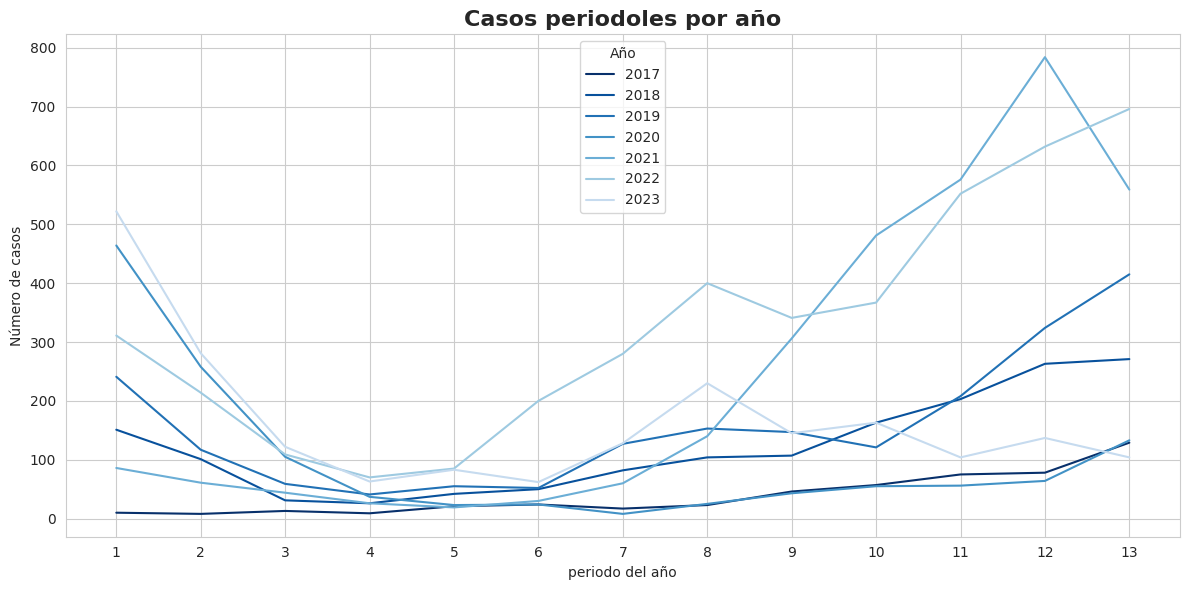

In [34]:
# Contar casos por periodo y año
conteo_periodol = df.groupby(['año', 'periodo']).size().reset_index(name='casos')

def graficar_casos_periodoles_por_año(df_conteo, nombre_grafico="Casos periodoles por año"):
    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")

    años = sorted(df_conteo['año'].unique())

    palette = ["#08306B", "#08519C", "#2171B5", "#4292C6", "#6BAED6", "#9ECAE1", "#C6DBEF"]
    colores = palette[:len(años)]  # selecciona N colores según la cantidad de años

    for i, año in enumerate(años):
        datos_año = df_conteo[df_conteo['año'] == año]
        plt.plot(
            datos_año['periodo'],
            datos_año['casos'],
            label=str(año),
            color=colores[i]
        )

    plt.title(nombre_grafico, fontsize=16, fontweight='bold')
    plt.xlabel("periodo del año")
    plt.ylabel("Número de casos")
    plt.xticks(range(1, 14))  # periodos ISO van de 1 a 53
    plt.legend(title="Año")
    plt.tight_layout()
    plt.show()

graficar_casos_periodoles_por_año(conteo_periodol)

In [35]:
# Agrupar y pivotear
conteo_periodol_periodol = df.groupby(['año', 'periodo']).size().reset_index(name='casos')
tabla_pivot = conteo_periodol.pivot(index='año', columns='periodo', values='casos').fillna(0).astype(int)
# Crear lista para almacenar resultados
resumen_periodos = []
for año in tabla_pivot.index:
    fila = tabla_pivot.loc[año]
    periodo_max = fila.idxmax()
    casos_max = fila.max()
    resumen_periodos.append({
        "año": año,
        "periodo_más_casos": periodo_max,
        "casos_máximos": casos_max,
    })
tabla_resumen = pd.DataFrame(resumen_periodos)
tabla_resumen


,año,periodo_más_casos,casos_máximos
0,2017,13,129
1,2018,13,271
2,2019,13,415
3,2020,1,464
4,2021,12,784
5,2022,13,696
6,2023,1,522


Al detallar los registros por la semana epidemiológica, se evidencia que existe un aumento de casos hacia los últimos meses de cada año, con algunos picos hacia la mitad del año.

En promedio, los casos se dan en su mayoría entre la semana 28 y la semana 44, con una media de distribución hacia la semana 30. Se destaca que el record de casos fue de 250 en la primera semana del 2023.

Con respecto a cada año, la mayor variabilidad se evidencia en el 2023. Los años 2021 y 2022, presentan notados picos de alza hacia finales de cada año. El 2017 y el 2020, son los años de manor variabilidad.